In [16]:
import torch
import nibabel as nib
import numpy as np
import sys
import glob
from natsort import natsorted
# import matplotlib.pyplot as plt
sys.path.append("../src")
from segment2d import *
from omegaconf import DictConfig, OmegaConf
import hydra
import matplotlib.pyplot as plt

In [73]:
list_image = natsorted(glob.glob("../data/CMR-MULTI/LGE_MULTI/SAX_TR/image/*"))[38:39]
list_mask = natsorted(glob.glob("../data/CMR-MULTI/LGE_MULTI/SAX_TR/anno/*"))[38:39]
count_z = 0
print(f"Total number of images: {len(list_image)}")
for i in range(len(list_image)):

    image = nib.load(list_image[i])
    array_image = image.get_fdata()
    mask = nib.load(list_mask[i])
    array_mask = mask.get_fdata().astype(np.int32)
    if len(array_image.shape) == 4:
        print(f"Image {list_image[i]} has 4 dimensions, taking the first volume.")
    # mask = nib.load(list_mask[i])
    # array_mask = mask.get_fdata().astype(np.int32)
    # find class weight for each class by dividing the total number of pixels by the number of pixels in each class
    count_z += array_image.shape[2]
print(f"Total number of pixels in all images: {count_z}")

Total number of images: 1
Total number of pixels in all images: 10


In [76]:
np.unique(array_mask[...,1], return_counts=True)

(array([0, 1, 3], dtype=int32), array([35892,  2522,  1586]))

-731.94482421875 2051.623291015625


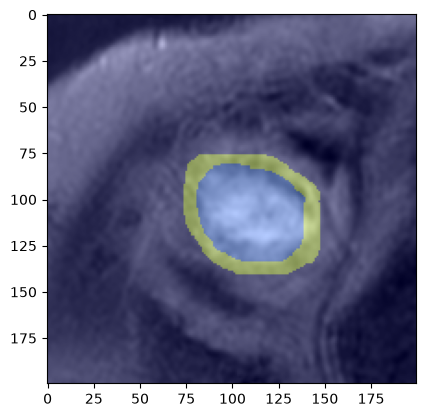

In [78]:

print(array_image.min(), array_image.max())
plt.imshow(array_image[:, :, 1], cmap='gray')
plt.imshow(array_mask[:, :, 1], cmap='jet', alpha=0.3, vmin=0, vmax=5)
# plt.colorbar()

In [79]:
import scipy.ndimage as ndi


def augment_scar_only_elastic(
    image,
    mask,
    scar_label=3,
    myo_label=2,
    alpha=25.0,
    sigma=8.0,
    roi_dilation=15,
    myo_dilation=2,
    boundary_sigma=1.5,
):
    """
    Elastic augmentation for myocardial scar only.

    image: 2D image, shape [H, W]
    mask:  2D mask, shape [H, W]
           1 = LV cavity
           2 = LV myocardium
           3 = scar
           4 = RV cavity

    Returns:
        aug_image, aug_mask
    """

    image = image.astype(np.float32)
    mask = mask.copy()

    scar = mask == scar_label
    myo = mask == myo_label

    if scar.sum() == 0:
        return image.copy(), mask.copy()

    h, w = image.shape

    # --------------------------------------------------
    # 1. Create random smooth deformation field
    # --------------------------------------------------
    dx = np.random.randn(h, w).astype(np.float32)
    dy = np.random.randn(h, w).astype(np.float32)

    dx = ndi.gaussian_filter(dx, sigma=sigma)
    dy = ndi.gaussian_filter(dy, sigma=sigma)

    dx *= alpha
    dy *= alpha

    # --------------------------------------------------
    # 2. Restrict deformation to scar neighborhood
    # --------------------------------------------------
    roi = ndi.binary_dilation(scar, iterations=roi_dilation)

    dx *= roi
    dy *= roi

    yy, xx = np.mgrid[:h, :w].astype(np.float32)
    coords = np.array([yy + dy, xx + dx])

    # --------------------------------------------------
    # 3. Warp scar mask
    # --------------------------------------------------
    scar_def = (
        ndi.map_coordinates(
            scar.astype(np.float32),
            coords,
            order=1,
            mode="constant",
            cval=0.0,
        )
        > 0.5
    )

    # --------------------------------------------------
    # 4. Keep deformed scar anatomically valid
    #    Scar should remain inside/near myocardium.
    # --------------------------------------------------
    myo_region = ndi.binary_dilation(myo | scar, iterations=myo_dilation)
    scar_def = scar_def & myo_region

    if scar_def.sum() == 0:
        return image.copy(), mask.copy()
    # --------------------------------------------------
    # 5. Warp full image
    # --------------------------------------------------
    image_def = ndi.map_coordinates(
        image,
        coords,
        order=1,
        mode="nearest"
    )

    # --------------------------------------------------
    # 6. Create new mask
    # --------------------------------------------------
    aug_mask = mask.copy()
    aug_mask[aug_mask == scar_label] = myo_label
    aug_mask[scar_def] = scar_label

    # --------------------------------------------------
    # 7. Smooth image transition near new scar
    # --------------------------------------------------
    boundary = ndi.gaussian_filter(scar_def.astype(np.float32), sigma=boundary_sigma)
    boundary = np.clip(boundary, 0.0, 1.0)

    blend_region = ndi.binary_dilation(scar | scar_def, iterations=roi_dilation)

    aug_image = image.copy()
    aug_image[blend_region] = (
        image_def[blend_region] * boundary[blend_region]
        + image[blend_region] * (1.0 - boundary[blend_region])
    )

    return aug_image, aug_mask

In [89]:
data = np.load("/home/nhattm/CMRSEG_Challange/data/CMR-MULTI_npz/LGE_MULTI/SAX/LGE_SAX_040_2_aug_1.npz")
image, mask = data["image"][...,0], data["mask"]
np.unique(mask, return_counts=True)

(array([0, 2, 3], dtype=uint8), array([61643,  3609,   284]))

In [81]:
img_aug, mask_aug = augment_scar_only_elastic(
    image, mask
)
np.unique(mask_aug, return_counts=True)

(array([0, 1, 2, 3], dtype=int32), array([35737,  2496,   192,  1575]))

In [82]:
np.unique(mask, return_counts=True)

(array([0, 1, 3], dtype=int32), array([35892,  2522,  1586]))

Text(0.5, 1.0, 'Augmented Image and Mask')

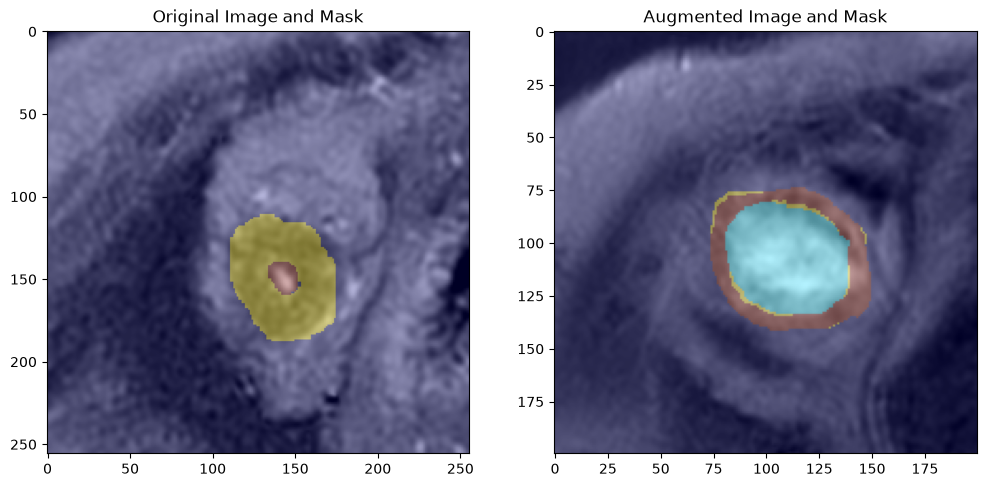

In [90]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(image, cmap="gray")
plt.imshow(mask, cmap="jet", alpha=0.3, )
plt.title("Original Image and Mask")
plt.subplot(1, 2, 2)
plt.imshow(img_aug, cmap="gray")
plt.imshow(mask_aug, cmap="jet", alpha=0.3, )
plt.title("Augmented Image and Mask")
# plt.colorbar()



In [118]:
cfg_data = OmegaConf.load("../config/data_config.yaml")

num_classes_dict = {k: cfg_data.CMR_MULTI.CINE_MULTI[k].num_classes for k in cfg_data.CMR_MULTI.CINE_MULTI.keys()}
class_weights_dict = {k: cfg_data.CMR_MULTI.CINE_MULTI[k].class_weights for k in cfg_data.CMR_MULTI.CINE_MULTI.keys()}

In [62]:
sax_files = natsorted(glob.glob("../data/CMR-MULTI_npz/CINE_MULTI/SAX/*"))[:12]
ch2_files = natsorted(glob.glob("../data/CMR-MULTI_npz/CINE_MULTI/2CH/*"))[:12]
ch4_files = natsorted(glob.glob("../data/CMR-MULTI_npz/CINE_MULTI/4CH/*"))[:12]


files_dict = {
    "SAX": sax_files,
    "2CH": ch2_files,
    "4CH": ch4_files,
}

dataset = MultiViewDataset(files_dict)
batch_sampler = SingleViewBatchSampler(dataset, batch_size=4)

loader = DataLoader(dataset, batch_sampler=batch_sampler, num_workers=4)
data = iter(loader)

In [68]:
image, mask, view = next(data)
view

('4CH', '4CH', '4CH', '4CH')

In [ ]:
# list_mask = natsorted(glob.glob("../data/CMR-MULTI/LGE_MULTI/RAS_TR/anno/*"))

# # count the number of pixels in each class in all masks in all images
# class_counts = {}
# for i in range(len(list_image)):

#     # image = nib.load(list_image[i])
#     # array_image = image.get_fdata()
#     mask = nib.load(list_mask[i])
#     array_mask = mask.get_fdata().astype(np.int32)
#     # find class weight for each class by dividing the total number of pixels by the number of pixels in each class
#     for class_index in np.unique(array_mask):
#         if class_index not in class_counts:
#             class_counts[class_index] = 0
#         class_counts[class_index] += np.sum(array_mask == class_index)
    
# # calculate class weight by divide the number of pixel 0
# class_weights = {}
# for class_index, count in class_counts.items():
#     class_weights[class_index] = (class_counts[0] / count).astype(np.float32)


# class_weights

{np.int32(0): np.float32(1.0), np.int32(1): np.float32(21.95373)}

In [137]:
import numpy as np
import matplotlib.pyplot as plt
data = np.load("/home/nhattm/CMRSEG_Challange/data/CMR-MULTI_npz/LGE_MULTI/SAX/LGE_SAX_001_4.npz")
image, mask = data["image"], data["mask"]

In [138]:
image.min(), image.max()

(np.float64(0.0042901731004901964), np.float64(0.9995710784313726))

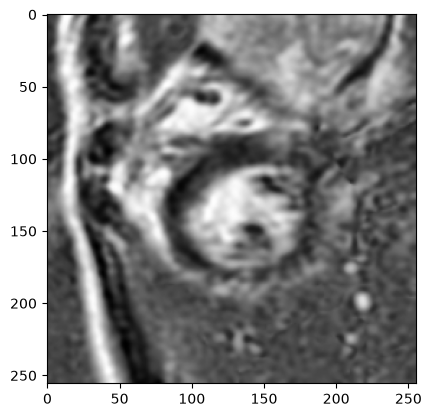

In [140]:
plt.imshow(image[:, :, 0], cmap="gray")
# plt.imshow(array_mask[:,:,0], alpha=0.5)